# Podstawy AI, 3. projekt:

PyTorch na CIFAR10 - zrobione zgodnie z tym poradnikiem (rozszerzone o wymagane zadania):
[Python Engineer CNN PyTorch Beginner 14](https://www.python-engineer.com/courses/pytorchbeginner/14-cnn/)

zrobione:
* ładowanie + preprocessing
* budowa CNN
* pętla treningu z walidacją w każdej epoce
* wykresy loss/accuracy
* inferencja na przykładowym obrazie

In [ ]:
# potrzebne importy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# konfiguracja wsparcia GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {device}')

## i "hyper-parameters" - parametry kontrolujące proces treningu
# liczba pętli treningu
num_epochs = 16
# liczba obrazów przetwarzanych naraz (więcej -> więcej użytego VRAM'u, szybszy trening)
batch_size = 4
# rozmiar kroku optymalizatora, tempo uczenia (małe kroki są bezpieczne, ale wolne)
learning_rate = 0.001

Using device: cuda


# 1. Preprocessing danych + ładowanie datasetu

In [ ]:
# dataset ma obrazki PILImage z zakresu [0, 1], które transofrmujemy do Tensor z zakresu [-1, 1]
# + normalizacja dla RGB
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

# ładowanie datasetu CIFAR10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# ładuje dane w batch'ach i miesza (shuffle) dane treningowe
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# definiujemy nazwy klas z CIFAR10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Training samples: 50000
Test samples: 10000


# 2. Budowa CNN

In [ ]:
# implementacja CNN'a
# dwie warstwy konwolucyjne z max pooling, 3 warstwy fully connected
class ConvNet(nn.Module):
  # setup warstw sieci
  def __init__(self):
    super(ConvNet, self).__init__()

    # ustawiamy rozmiary: 3 - bo RGB, 6 - liczba filtrów, 5 - kernel 5*5
    self.conv1 = nn.Conv2d(3, 6, 5)
    # zmniejsza wymiary o połowę - kernel 2x2, stride 2
    self.pool = nn.MaxPool2d(2, 2)
    # input musi być taki jak output poprzedniej
    self.conv2 = nn.Conv2d(6, 16, 5)

    # warstwa fully connected, liniowe
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    # wyjście na 10, bo mamy 10 różnych klas
    self.fc3 = nn.Linear(84, 10)

  # użycie tych warst w forward pass'ie
  def forward(self, x):
    # użycie Conv + ReLU + Pooling
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))

    # spłaszczamy przed podaniem do pierwszej warstwy fully connected (-1 dla automatycznego obliczenia batch size)
    x = x.view(-1, 16 * 5 * 5)

    # warstwy fully connected z ReLU
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    # tu ostatnia warstwa bez funkcji aktywacji
    x = self.fc3(x)

    return x

In [ ]:
# tworzymy model i przenosimy na GPU
model = ConvNet().to(device)

print(f'Model architecture: {model}')

## funkcja loss i optymalizator
# CrossEntropyLoss() bo to klasyfikacja wieloklasowa - od razu zawiera SoftMax
criterion = nn.CrossEntropyLoss()
# a tu używamy stochastic gradient descent
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Model architecture: ConvNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


# 3. Pętla treningu z walidacją w każdej epoce

In [ ]:
# funkcja walidacji - zwraca średni loss i accuracy
def evaluate_model(model, dataloader, criterion, device):
  # przejście w tryb ewaluacji, wyłącza droput i batch norm
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)

      # forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      # statystyki
      running_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  avg_loss = running_loss / len(dataloader)
  accuracy = 100 * correct / total

  return avg_loss, accuracy

In [ ]:
# listy do przechowywania metryk dla wykresów
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# pętla w której trenujemy model
n_total_steps = len(train_loader)

for epoch in range(num_epochs):
  # tryb treningu
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for i, (images, labels) in enumerate(train_loader):
    # przesłanie obrazków i lebel'ek do GPU
    images = images.to(device)
    labels = labels.to(device)

    # forward pass - obliczenie predykcji i loss
    outputs = model(images)
    loss = criterion(outputs, labels)

    ## backward pass - obliczenie gradientów
    # wyzerowanie z poprzedniego korku
    optimizer.zero_grad()
    # backpropagation
    loss.backward()
    # aktualizacja wag
    optimizer.step()

    # zbieranie statystyk treningowych
    running_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  # oblicz metryki treningowe dla całej epoki
  train_loss = running_loss / len(train_loader)
  train_acc = 100 * correct / total

  # WALIDACJA PO KAŻDEJ EPOCE - tutaj
  val_loss, val_acc = evaluate_model(model, test_loader, criterion, device)

  # zapisanie metryk do list
  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  # dodatkowo podsumowanie epoki:
  print(f'EPOCH [{epoch+1}/{num_epochs}] SUMMARY:')
  print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%')
  print(f'Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.2f}%')


print('Finished Training')

EPOCH [1/16] SUMMARY:
Train Loss: 2.2898 | Train Accuracy: 15.21%
Val Loss:   2.2088 | Val Accuracy:   19.86%
EPOCH [2/16] SUMMARY:
Train Loss: 1.9557 | Train Accuracy: 28.89%
Val Loss:   1.7614 | Val Accuracy:   34.77%
EPOCH [3/16] SUMMARY:
Train Loss: 1.6650 | Train Accuracy: 38.89%
Val Loss:   1.5604 | Val Accuracy:   43.21%
EPOCH [4/16] SUMMARY:
Train Loss: 1.5272 | Train Accuracy: 44.58%
Val Loss:   1.4570 | Val Accuracy:   46.94%
EPOCH [5/16] SUMMARY:
Train Loss: 1.4356 | Train Accuracy: 48.28%
Val Loss:   1.3975 | Val Accuracy:   49.17%
EPOCH [6/16] SUMMARY:
Train Loss: 1.3701 | Train Accuracy: 50.79%
Val Loss:   1.3442 | Val Accuracy:   51.61%
EPOCH [7/16] SUMMARY:
Train Loss: 1.3168 | Train Accuracy: 52.81%
Val Loss:   1.3051 | Val Accuracy:   52.71%
EPOCH [8/16] SUMMARY:
Train Loss: 1.2688 | Train Accuracy: 54.55%
Val Loss:   1.2667 | Val Accuracy:   54.21%
EPOCH [9/16] SUMMARY:
Train Loss: 1.2279 | Train Accuracy: 56.25%
Val Loss:   1.2521 | Val Accuracy:   55.00%
EPOCH [10/

In [ ]:
## ocena modelu - z tutoriala
# wyłączamy gradient, żeby zaoszczędzić pamięć
with torch.no_grad():
  n_correct = 0
  n_samples = 0
  n_class_correct = [0 for i in range(10)]
  n_class_samples = [0 for i in range(10)]

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)

    # torch.max zwraca (value, index) - bierzemy indeks
    _, predicted = torch.max(outputs, 1)
    n_samples += labels.size(0)
    n_correct += (predicted == labels).sum().item()

    # zliczamy accuracy dla każdej klasy
    for i in range(len(labels)):
      label = labels[i]
      pred = predicted[i]
      if (label == pred):
        n_class_correct[label] += 1
      n_class_samples[label] += 1

  # + ogólna poprawność
  acc = 100.0 * n_correct / n_samples
  print(f'Accuracy: {acc}%')

  for i in range(10):
    acc = 100.0 * n_class_correct[i] / n_class_samples[i]
    print(f'Accuracy for {classes[i]}: {acc}%')

Accuracy: 60.75%
Accuracy for plane: 56.9%
Accuracy for car: 64.3%
Accuracy for bird: 51.7%
Accuracy for cat: 35.5%
Accuracy for deer: 52.3%
Accuracy for dog: 60.0%
Accuracy for frog: 65.9%
Accuracy for horse: 71.0%
Accuracy for ship: 82.0%
Accuracy for truck: 67.9%


# 4. Wykresy loss/accuracy

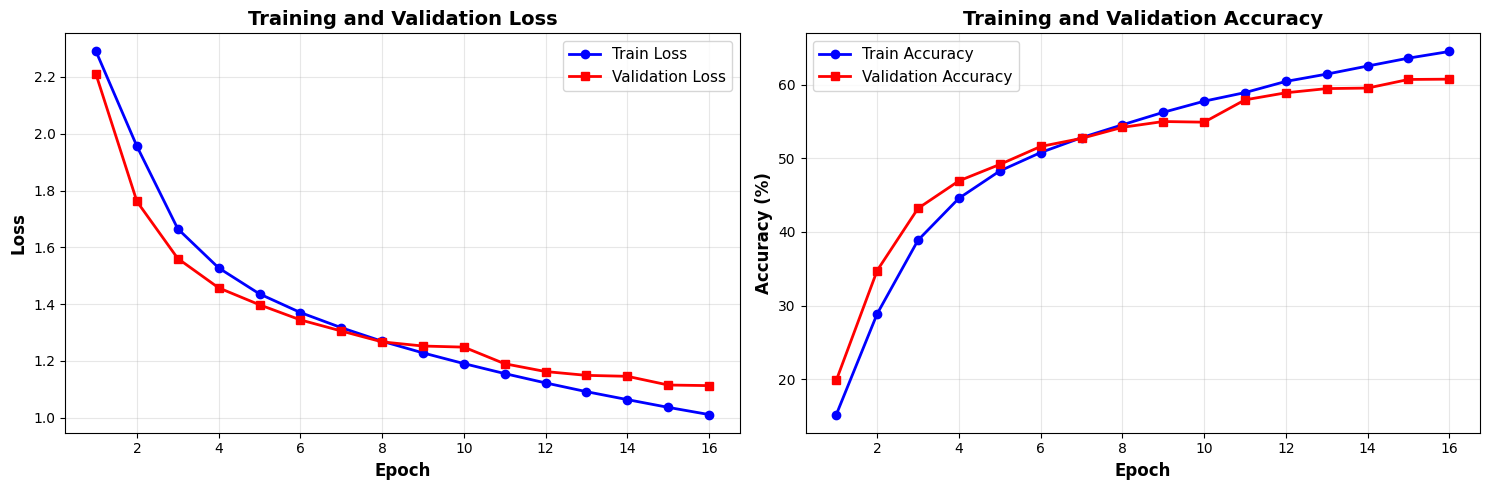

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# wykres loss
epochs_range = range(1, num_epochs + 1)
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# wykres accuracy
ax2.plot(epochs_range, train_accuracies, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, val_accuracies, 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Inferencja na przykładowym obrazie

In [ ]:
# losowy batch z test set
dataiter = iter(test_loader)
images, labels = next(dataiter)

# pierwszy obraz
sample_idx = 0
sample_img = images[sample_idx].unsqueeze(0).to(device)
true_label = labels[sample_idx].item()

# predykcja
model.eval()
with torch.no_grad():
  output = model(sample_img)

  # obliczenie prawdopodobieństwa - softmax
  probabilities = F.softmax(output, dim=1)
  confidence, predicted = torch.max(probabilities, 1)
  predicted_label = predicted.item()
  confidence_pct = confidence.item() * 100

## wizualizacja
fig = plt.figure(figsize=(12, 5))

# subplot - obraz
plt.subplot(1, 2, 1)
# "odnormalizacja" z [-1,1] do [0,1]
img = images[sample_idx] / 2 + 0.5
npimg = img.numpy()
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title(f'True Label: {classes[true_label]}', fontsize=14, fontweight='bold')
plt.axis('off')

# subplot - prawdopodobieństwa dla wszystkich klas
plt.subplot(1, 2, 2)
probs = probabilities[0].cpu().numpy()
colors = ['green' if i == predicted_label else 'skyblue' for i in range(10)]
bars = plt.barh(classes, probs, color=colors)
plt.xlabel('Probability', fontsize=12, fontweight='bold')
plt.title(f'Predicted: {classes[predicted_label]} ({confidence_pct:.1f}%)', fontsize=14, fontweight='bold', color='green' if predicted_label == true_label else 'red')
plt.xlim([0, 1])
plt.grid(axis='x', alpha=0.3)

# dodaje wartości na słupkach
for bar, prob in zip(bars, probs):
    if prob > 0.05:
        plt.text(prob + 0.02, bar.get_y() + bar.get_height()/2, f'{prob:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

NameError: name 'test_loader' is not defined

In [ ]:
# wyświetl szczegóły predykcji
print(f'True label:     {classes[true_label]}')
print(f'Predicted:      {classes[predicted_label]}')
print(f'Confidence:     {confidence_pct:.2f}%')
print(f'Result:         {"CORRECT" if predicted_label == true_label else "WRONG"}')

# top 3 predykcje
print('Top 3 predictions:')
print('-' * 40)
top3_prob, top3_idx = torch.topk(probabilities[0], 3)
for i in range(3):
    print(f'{i+1}. {classes[top3_idx[i]]:10s}: {top3_prob[i].item()*100:6.2f}%')


True label:     cat
Predicted:      frog
Confidence:     29.02%
Result:         WRONG
Top 3 predictions:
----------------------------------------
1. frog      :  29.02%
2. bird      :  23.88%
3. cat       :  18.98%
